In [1]:

#importing pandas library which contains the functions related to the database manipulation activities
import pandas as pd

In [2]:
#dataset is is loaded from "Dataset"  a folder placed alongside this .ipynb file"
dataset=pd.read_csv("Dataset/50_Startups.csv")

In [3]:
# to Check the values of the dataset
dataset

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.95,311613.29,New York,152211.77
9,123334.88,108679.17,304981.62,California,149759.96


In [4]:
#for creating the one hot encoding which is a process of quantizing the string into numerical value to enable it for the usage in ML system and "drop_first= True " to drop the First column of one hot encoding to minimize the column
dataset=pd.get_dummies(dataset,drop_first=True)

In [5]:
# to Check the values of the dataset with one hot encoding except the first column of it
dataset

,R&D Spend,Administration,Marketing Spend,Profit,State_Florida,State_New York
0,165349.20,136897.80,471784.10,192261.83,False,True
1,162597.70,151377.59,443898.53,191792.06,False,False
2,153441.51,101145.55,407934.54,191050.39,True,False
3,144372.41,118671.85,383199.62,182901.99,False,True
4,142107.34,91391.77,366168.42,166187.94,True,False
5,131876.90,99814.71,362861.36,156991.12,False,True
6,134615.46,147198.87,127716.82,156122.51,False,False
7,130298.13,145530.06,323876.68,155752.60,True,False
8,120542.52,148718.95,311613.29,152211.77,False,True
9,123334.88,108679.17,304981.62,149759.96,False,False


In [6]:
dataset.columns

Index(['R&D Spend', 'Administration', 'Marketing Spend', 'Profit',
       'State_Florida', 'State_New York'],
      dtype='object')

In [7]:
#creating the independent by splitting from original dataset serves as input 
independent=dataset[['R&D Spend', 'Administration', 'Marketing Spend','State_Florida', 'State_New York']]

In [8]:
# to display independent table
independent

,R&D Spend,Administration,Marketing Spend,State_Florida,State_New York
0,165349.20,136897.80,471784.10,False,True
1,162597.70,151377.59,443898.53,False,False
2,153441.51,101145.55,407934.54,True,False
3,144372.41,118671.85,383199.62,False,True
4,142107.34,91391.77,366168.42,True,False
5,131876.90,99814.71,362861.36,False,True
6,134615.46,147198.87,127716.82,False,False
7,130298.13,145530.06,323876.68,True,False
8,120542.52,148718.95,311613.29,False,True
9,123334.88,108679.17,304981.62,False,False


In [9]:
#creating the independent by splitting from original dataset serves as output which is the label 
dependent=dataset[["Profit"]]

In [10]:
#Splitting the Rows of data as a part for Training the model and and another part for Testing the model's performance using four variables 2 from dependent and 2 from independent 
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(independent, dependent, test_size=0.30,random_state=0)


In [11]:
from sklearn.tree import DecisionTreeRegressor
regressor = DecisionTreeRegressor()
dt_regressor_Default = regressor.fit(X_train,y_train)

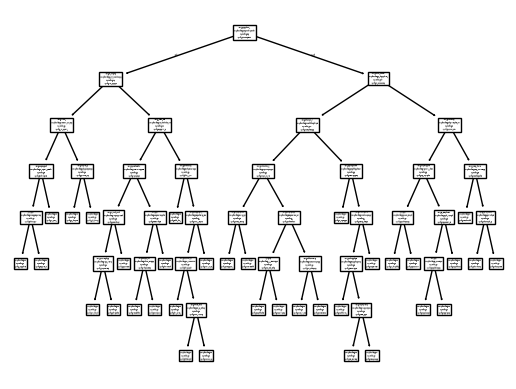

In [12]:
import matplotlib.pyplot as plt
from sklearn import tree
tree.plot_tree(dt_regressor_Default)
plt.show()

Predicting with the Default Parameters without Tweaking the Parametric values

In [13]:
#Predicting function usage to predict value for the given x in test portion which was not used for training
y_pred_dt  = dt_regressor_Default.predict(X_test)
print(y_pred_dt)

[101004.64 141585.52 141585.52  90708.19 182901.99 111313.02  78239.91
  99937.59 111313.02 156991.12 107404.34  89949.14 126992.93  89949.14
 125370.37]


In [14]:
from sklearn.metrics import r2_score

#importing the function r2 a scoring system from sklearn to check the difference in the value of "predicted y" and the actual value of "labeled y" and squaring it for maximizing the difference . 

r_score_DT_Default  = (r2_score(y_test,y_pred_dt))

print(r_score_DT_Default)

0.9267443086260378


Predicting with the Multiple Parametric Combinations without Tweaked the Parametric values and check multiple Results

In [15]:
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import r2_score


In [107]:
def describe_article(paramA, paramB, paramC):
    """
    Returns a description string for an article based on its
    size, shape, and colour.
    """
    return f"The result of the parametric combinations of Criterion:{paramA} , Splitter:{paramB} , Max_features:{paramC} . are:"


def main():
    criterion_List = ["squared_error", "absolute_error", "poisson"]
    splitter_List = ["best", "random"]
    max_features_List = ["sqrt", "log2",.1,.2,.3,.4,.5,.6,.7,.8,.9,1]
    result_List=[]

    count = 0
    for criterionVal in criterion_List:
        for splitterVal in splitter_List:
            for max_featuresVal in max_features_List:
                count += 1
                regressor = DecisionTreeRegressor(criterion = criterionVal ,splitter = splitterVal , max_features = max_featuresVal)
                dt_regressor = regressor.fit(X_train,y_train)
                y_pred_dt  = dt_regressor.predict(X_test)
                r_score_DT  = (r2_score(y_test,y_pred_dt))    
                result_List.append(r_score_DT)         
                print(f"{count}. {describe_article(criterionVal, splitterVal, max_featuresVal)} {r_score_DT} ")
                

    print(f"\nTotal combinations printed: {count}")
    print("the max value among the Result is :"+ str(result_List.index(max(result_List))+1))


if __name__ == "__main__":
    main()

1. The result of the parametric combinations of Criterion:squared_error , Splitter:best , Max_features:sqrt . are: 0.9177583563013055 
2. The result of the parametric combinations of Criterion:squared_error , Splitter:best , Max_features:log2 . are: 0.35881958327216856 
3. The result of the parametric combinations of Criterion:squared_error , Splitter:best , Max_features:0.1 . are: 0.349603982356821 
4. The result of the parametric combinations of Criterion:squared_error , Splitter:best , Max_features:0.2 . are: -0.5479891903496925 
5. The result of the parametric combinations of Criterion:squared_error , Splitter:best , Max_features:0.3 . are: 0.10717485587645004 
6. The result of the parametric combinations of Criterion:squared_error , Splitter:best , Max_features:0.4 . are: 0.23338992436715988 
7. The result of the parametric combinations of Criterion:squared_error , Splitter:best , Max_features:0.5 . are: 0.7163465014525923 
8. The result of the parametric combinations of Criterion

Considering the 12 Sample outputs
47. The result of the parametric combinations of Criterion:absolute_error , Splitter:random , Max_features:0.9 . are: 0.9500822515107457 
35. The result of the parametric combinations of Criterion:absolute_error , Splitter:best , Max_features:0.9 . are: 0.9666963579056695 
34. The result of the parametric combinations of Criterion:absolute_error , Splitter:best , Max_features:0.8 . are: 0.9815848909074392 
34. The result of the parametric combinations of Criterion:absolute_error , Splitter:best , Max_features:0.8 . are: 0.9539063107132314 
32. The result of the parametric combinations of Criterion:absolute_error , Splitter:best , Max_features:0.6 . are: 0.9711342373037836 
34. The result of the parametric combinations of Criterion:absolute_error , Splitter:best , Max_features:0.8 . are: 0.9750009521321548 
46. The result of the parametric combinations of Criterion:absolute_error , Splitter:random , Max_features:0.8 . are: 0.942992377135281 
71. The result of the parametric combinations of Criterion:poisson , Splitter:random , Max_features:0.9 . are: 0.9658692261818285 
58. The result of the parametric combinations of Criterion:poisson , Splitter:best , Max_features:0.8 . are: 0.9489004967105426 
58. The result of the parametric combinations of Criterion:poisson , Splitter:best , Max_features:0.8 . are: 0.9418836366874392 
34. The result of the parametric combinations of Criterion:absolute_error , Splitter:best , Max_features:0.8 . are: 0.9494973063749428 
35. The result of the parametric combinations of Criterion:absolute_error , Splitter:best , Max_features:0.9 . are: 0.968651748619661 

THE BEST RESULT KEEPS VARIES FROM TIME TO TIME BY DIFFERENT RUNS , AS RESULT THE ALGORITHM IS A RANDOMIZED 

Considering the float range of max_features parameter from 0.5 to 0.9 we will minimize Iteration


In [ ]:
def describe_article(paramA, paramB, paramC):
    """
    Returns a description string for an article based on its
    size, shape, and colour.
    """
    return f"The result of the parametric combinations of Criterion:{paramA} , Splitter:{paramB} , Max_features:{paramC} . are:"


def main():
    criterion_List = ["squared_error", "absolute_error", "poisson"]
    splitter_List = ["best", "random"]
    max_features_List = ["sqrt", "log2",.5,.6,.7,.8,.9]
    result_List=[]
    dt_regressor_List = []

    count = 0
    for criterionVal in criterion_List:
        for splitterVal in splitter_List:
            for max_featuresVal in max_features_List:
                count += 1
                regressor = DecisionTreeRegressor(criterion = criterionVal ,splitter = splitterVal , max_features = max_featuresVal)
                dt_regressor = regressor.fit(X_train,y_train)
                y_pred_dt  = dt_regressor.predict(X_test)
                r_score_DT  = (r2_score(y_test,y_pred_dt))    
                result_List.append(r_score_DT) 
                dt_regressor_List.append(dt_regressor)        
                print(f"{count}. {describe_article(criterionVal, splitterVal, max_featuresVal)} {r_score_DT} ")
                

    print(f"\nTotal combinations printed: {count}")
    print("the max value among the Result is S.No :"+ str(result_List.index(max(result_List))+1) + " Which is " + str(max(result_List) ))
    #print(dt_regressor_List)
    best_Fited_Regressor = dt_regressor_List[int(result_List.index(max(result_List)))]
    return best_Fited_Regressor


if __name__ == "__main__":
    #getting the Best Fit from the List
    best_Regressor = main()
    


1. The result of the parametric combinations OF criterion :squared_error splitter :best max_features :sqrt. are : 0.49376528621808335 
2. The result of the parametric combinations OF criterion :squared_error splitter :best max_features :log2. are : 0.78595656172054 
3. The result of the parametric combinations OF criterion :squared_error splitter :best max_features :0.5. are : 0.7637520767864423 
4. The result of the parametric combinations OF criterion :squared_error splitter :best max_features :0.6. are : 0.9481841681231585 
5. The result of the parametric combinations OF criterion :squared_error splitter :best max_features :0.7. are : 0.756948682694516 
6. The result of the parametric combinations OF criterion :squared_error splitter :best max_features :0.8. are : 0.7423000077754102 
7. The result of the parametric combinations OF criterion :squared_error splitter :best max_features :0.9. are : 0.7356247083987663 
8. The result of the parametric combinations OF criterion :squared_er

In [76]:

# Importing the pickling function to pickle the best model which is using linear as Kernel Parameter.
import pickle
# Assigning the variable for filename
filename="Saved_Model/finalized_bestRegressor.sav"
# dump function of pickle to write the pickled structure as a file from the variable used for file name
pickle.dump(best_Regressor,open(filename,'wb'))

Deployment Section

In [79]:
# load function of pickle to read the pickled structure from the already saved "finalized_model_Mul_linear.sav"
loaded_model=pickle.load(open("Saved_Model/finalized_bestRegressor.sav",'rb'))
#Predicting the result for the input "1234,345,4565,1,0" the order of items to be same as the training
result=loaded_model.predict([[1234,345,4565,1,0]])
print(f"The Result is {result[0] : .4f}")


The Result is  49490.7500


c:\Users\haris\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
